### Ejercicio Dataset Vinos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file = "C:/Users/Jose Manuel/Documents/VisualStudioCode_Workspace/Repo_CEDAPY/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/DATASETS/wines_SPA.csv"
df_wines = pd.read_csv(file, sep=',', engine= 'python')
df_wines.head(10)

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0
5,Vega Sicilia,Unico,1998,4.8,1209,Espana,Ribera del Duero,490.00,Ribera Del Duero Red,5.0,3.0
6,Vega Sicilia,Unico,2010,4.8,1201,Espana,Ribera del Duero,349.00,Ribera Del Duero Red,5.0,3.0
7,Vega Sicilia,Unico,1995,4.8,926,Espana,Ribera del Duero,810.89,Ribera Del Duero Red,5.0,3.0
8,Vega Sicilia,Unico Reserva Especial Edicion,2015,4.8,643,Espana,Ribera del Duero,345.00,Ribera Del Duero Red,5.0,3.0
9,Vega Sicilia,Unico,2011,4.8,630,Espana,Ribera del Duero,315.00,Ribera Del Duero Red,5.0,3.0


In [3]:
print(df_wines.shape)

(7500, 11)


- Vemos que el dataset tiene un total de 7500 registros en 11 columnas.


In [4]:
df_wines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       7500 non-null   object 
 1   wine         7500 non-null   object 
 2   year         7498 non-null   object 
 3   rating       7500 non-null   float64
 4   num_reviews  7500 non-null   int64  
 5   country      7500 non-null   object 
 6   region       7500 non-null   object 
 7   price        7500 non-null   float64
 8   type         6955 non-null   object 
 9   body         6331 non-null   float64
 10  acidity      6331 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 644.7+ KB


- Podemos observar el tipo de datos viendo los que son númericos de los que son objetos.
- Se observa también de que las columnas tipo, cuerpo y acidez presentan bastantes datos que en principio parecen nulos

In [5]:
null_type = df_wines['type'].isnull().sum()
null_body = df_wines['body'].isnull().sum()
null_acidity = df_wines['acidity'].isnull().sum()
print(f"Nulos de tipo: {null_type}\nNulos de cuerpo: {null_body}\nNulos de acidez: {null_acidity}")

Nulos de tipo: 545
Nulos de cuerpo: 1169
Nulos de acidez: 1169


In [6]:
df_wines.describe()

,rating,num_reviews,price,body,acidity
count,7500.000000,7500.000000,7500.000000,6331.000000,6331.000000
mean,4.254933,451.109067,60.095822,4.158427,2.946612
std,0.118029,723.001856,150.356676,0.583352,0.248202
min,4.200000,25.000000,4.990000,2.000000,1.000000
25%,4.200000,389.000000,18.900000,4.000000,3.000000
50%,4.200000,404.000000,28.530000,4.000000,3.000000
75%,4.200000,415.000000,51.350000,5.000000,3.000000
max,4.900000,32624.000000,3119.080000,5.000000,3.000000


- Podemos ver que hay una gran desviación entre los precios donde el mínimo esta en 5€ y el máximo en 3.119€ lo que propicia que la media no sea muy representativa. Habra que mirar como estan distribuidos eso precios.
- Por el contrario los datos de rating, cuerpo y acidez no son tan dispersos, por lo que los datos de media son más representativos y fiables.
- Vamos a eliminar las filas que contengan valores nulos con el método dropna().

In [7]:
df_wines = df_wines.dropna(subset=['type', 'body','acidity', 'year'])
display(df_wines.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6329 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       6329 non-null   object 
 1   wine         6329 non-null   object 
 2   year         6329 non-null   object 
 3   rating       6329 non-null   float64
 4   num_reviews  6329 non-null   int64  
 5   country      6329 non-null   object 
 6   region       6329 non-null   object 
 7   price        6329 non-null   float64
 8   type         6329 non-null   object 
 9   body         6329 non-null   float64
 10  acidity      6329 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 593.3+ KB


None

- Ahora tenemos 6329 registros para proceder con el estudio del dataset

In [8]:
# Configurar Pandas para mostrar todas las filas y columnas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
wines_type = df_wines.groupby('type')['wine'].count().sort_values(ascending=False)
print(wines_type)

type
Rioja Red               2143
Ribera Del Duero Red    1277
Red                      787
Priorat Red              620
Tempranillo              267
Toro Red                 261
Sherry                   252
Albarino                 225
Mencia                   213
Rioja White               86
Pedro Ximenez             35
Grenache                  33
Cava                      29
Verdejo                   26
Monastrell                17
Montsant Red              14
Chardonnay                13
Syrah                     13
Cabernet Sauvignon        10
Sparkling                  5
Sauvignon Blanc            3
Name: wine, dtype: int64


- Con este resultado podemos ver, que los tipos de vinos más presentes en el dataset son Rioja y Ribera del Duero, mientras que el tipo de Sauvignon blanco apenas hay datos del mismo.

In [15]:
bodegas = df_wines.groupby('winery')['wine'].count().sort_values(ascending=False)
print(bodegas)

winery
Contino                                             414
Artadi                                              239
La Rioja Alta                                       228
Sierra Cantabria                                    215
Vina Pedrosa                                        207
Matarromera                                         206
Imperial                                            206
Losada                                              206
Portal del Priorat                                  204
Sei Solo                                            204
Ramon Bilbao                                        203
Campillo                                            202
Bodegas La Horra                                    202
Matsu                                               202
La Vicalanda                                        202
Conreria d'Scala Dei                                201
Mustiguillo                                         201
Mar de Frades                            

- Se observa las bodegas que presentan mayor cantidad de vinos presentes en el dataset, en este caso la bodega Contino es la que más vinos tiene con un total de 414, seguida de Artadi con 239 vinos.

In [10]:
menor60 = 0
mayor60 = 0
for x in df_wines['price']:
    if(x < 60):
        menor60 +=1
    else:
        mayor60 +=1
print(f"Los vinos de menos de 60 euros son: {menor60} y los de más de 60 euros son: {mayor60}")

Los vinos de menos de 60 euros son: 4737 y los de más de 60 euros son: 1592


In [22]:
regiones = df_wines.groupby('region')['wine'].count().sort_values(ascending=False)
print(regiones)

region
Rioja                              2221
Ribera del Duero                   1280
Priorato                            622
Toro                                264
Vino de Espana                      239
Jerez-Xeres-Sherry                  225
Rias Baixas                         224
Bierzo                              216
Costers del Segre                   208
Alicante                            206
El Terrerazo                        201
Castilla y Leon                      44
Cava                                 30
Jumilla                              25
Montilla-Moriles                     25
Emporda                              23
Sardon de Duero                      18
Rueda                                16
Montsant                             16
Somontano                            15
Mallorca                             15
Campo de Borja                       15
Penedes                              14
Rioja Alta                           13
Jerez Amontillado                

+ Podemos ver que los vinos que más predominan son los tintos y dentro de estos los de Ribera y Rioja ocupan las primeras posiciones con una gran diferencia con el resto.

In [20]:
years = df_wines.groupby('year').count().sort_values(by='year', ascending=False)
print(years)

      winery  wine  rating  num_reviews  country  region  price  type  body  \
year                                                                          
N.V.     259   259     259          259      259     259    259   259   259   
2021       5     5       5            5        5       5      5     5     5   
2020      17    17      17           17       17      17     17    17    17   
2019     279   279     279          279      279     279    279   279   279   
2018     752   752     752          752      752     752    752   752   752   
2017     652   652     652          652      652     652    652   652   652   
2016     810   810     810          810      810     810    810   810   810   
2015     775   775     775          775      775     775    775   775   775   
2014     338   338     338          338      338     338    338   338   338   
2013      58    58      58           58       58      58     58    58    58   
2012     480   480     480          480      480    

+ En lo que respecta a loa años, se puede observar como según los datos del dataset, la mayoría de los vinos son del 2010 en adelante, destacando años como el 2011 y 2012 y del 2015 al 2019.

### Gráfico variables númericas

<Axes: xlabel='acidity', ylabel='Count'>

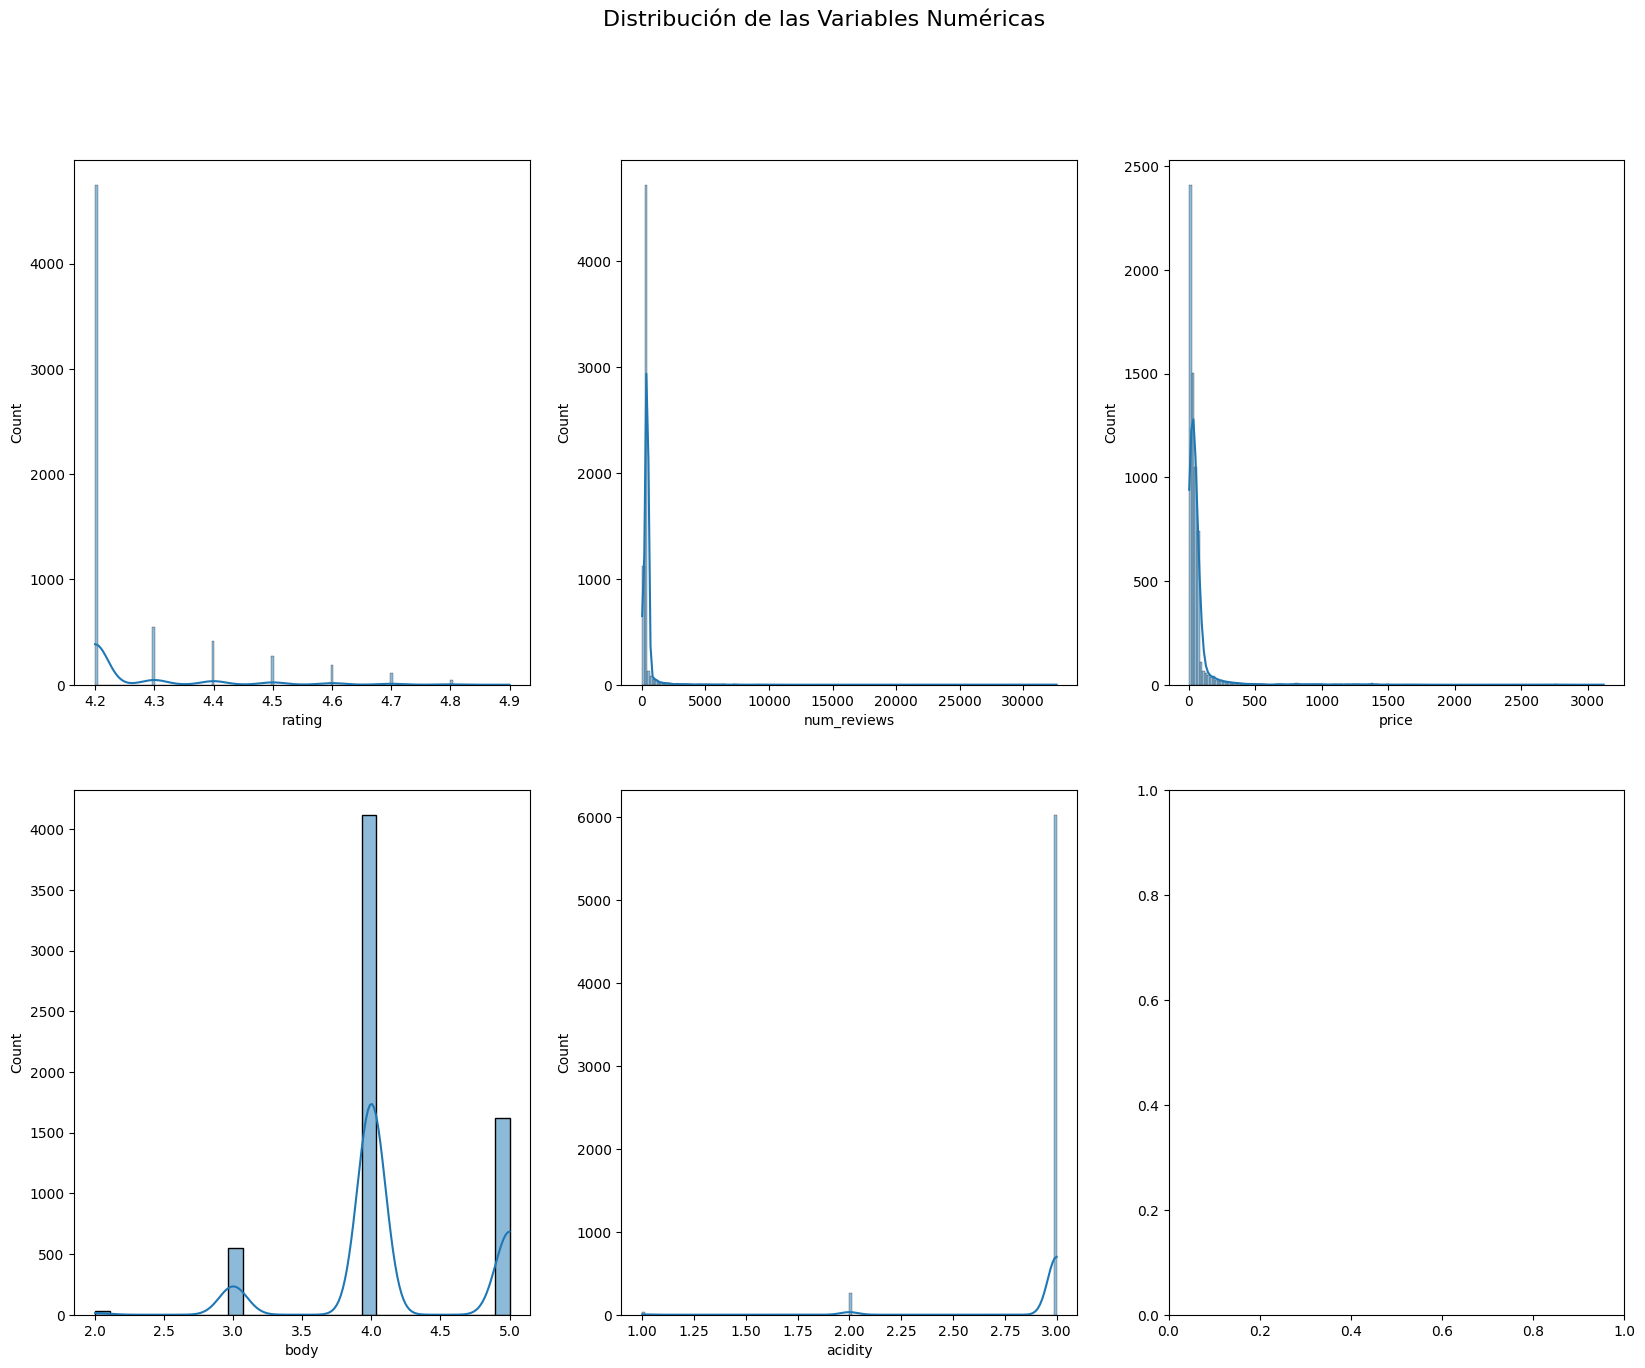

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15)) # Gráfico que contiene 4 subgráficos (2 filas x 3 columnas)
fig.suptitle('Distribución de las Variables Numéricas', fontsize=16)
sns.histplot(data=df_wines, x='rating', kde=True, ax=axes[0,0])
sns.histplot(data=df_wines, x='num_reviews', kde=True, ax=axes[0,1])
sns.histplot(data=df_wines, x='price', kde=True, ax=axes[0,2])
sns.histplot(data=df_wines, x='body', kde=True, ax=axes[1,0])
sns.histplot(data=df_wines, x='acidity', kde=True, ax=axes[1,1])

-

### Variables CATEGÓRICAS

- Creamos gráfico de los distintos tipos de vino y otro de los vinos en varios rangos de años.

Text(0.5, 1.0, 'Conteo por rango de años')

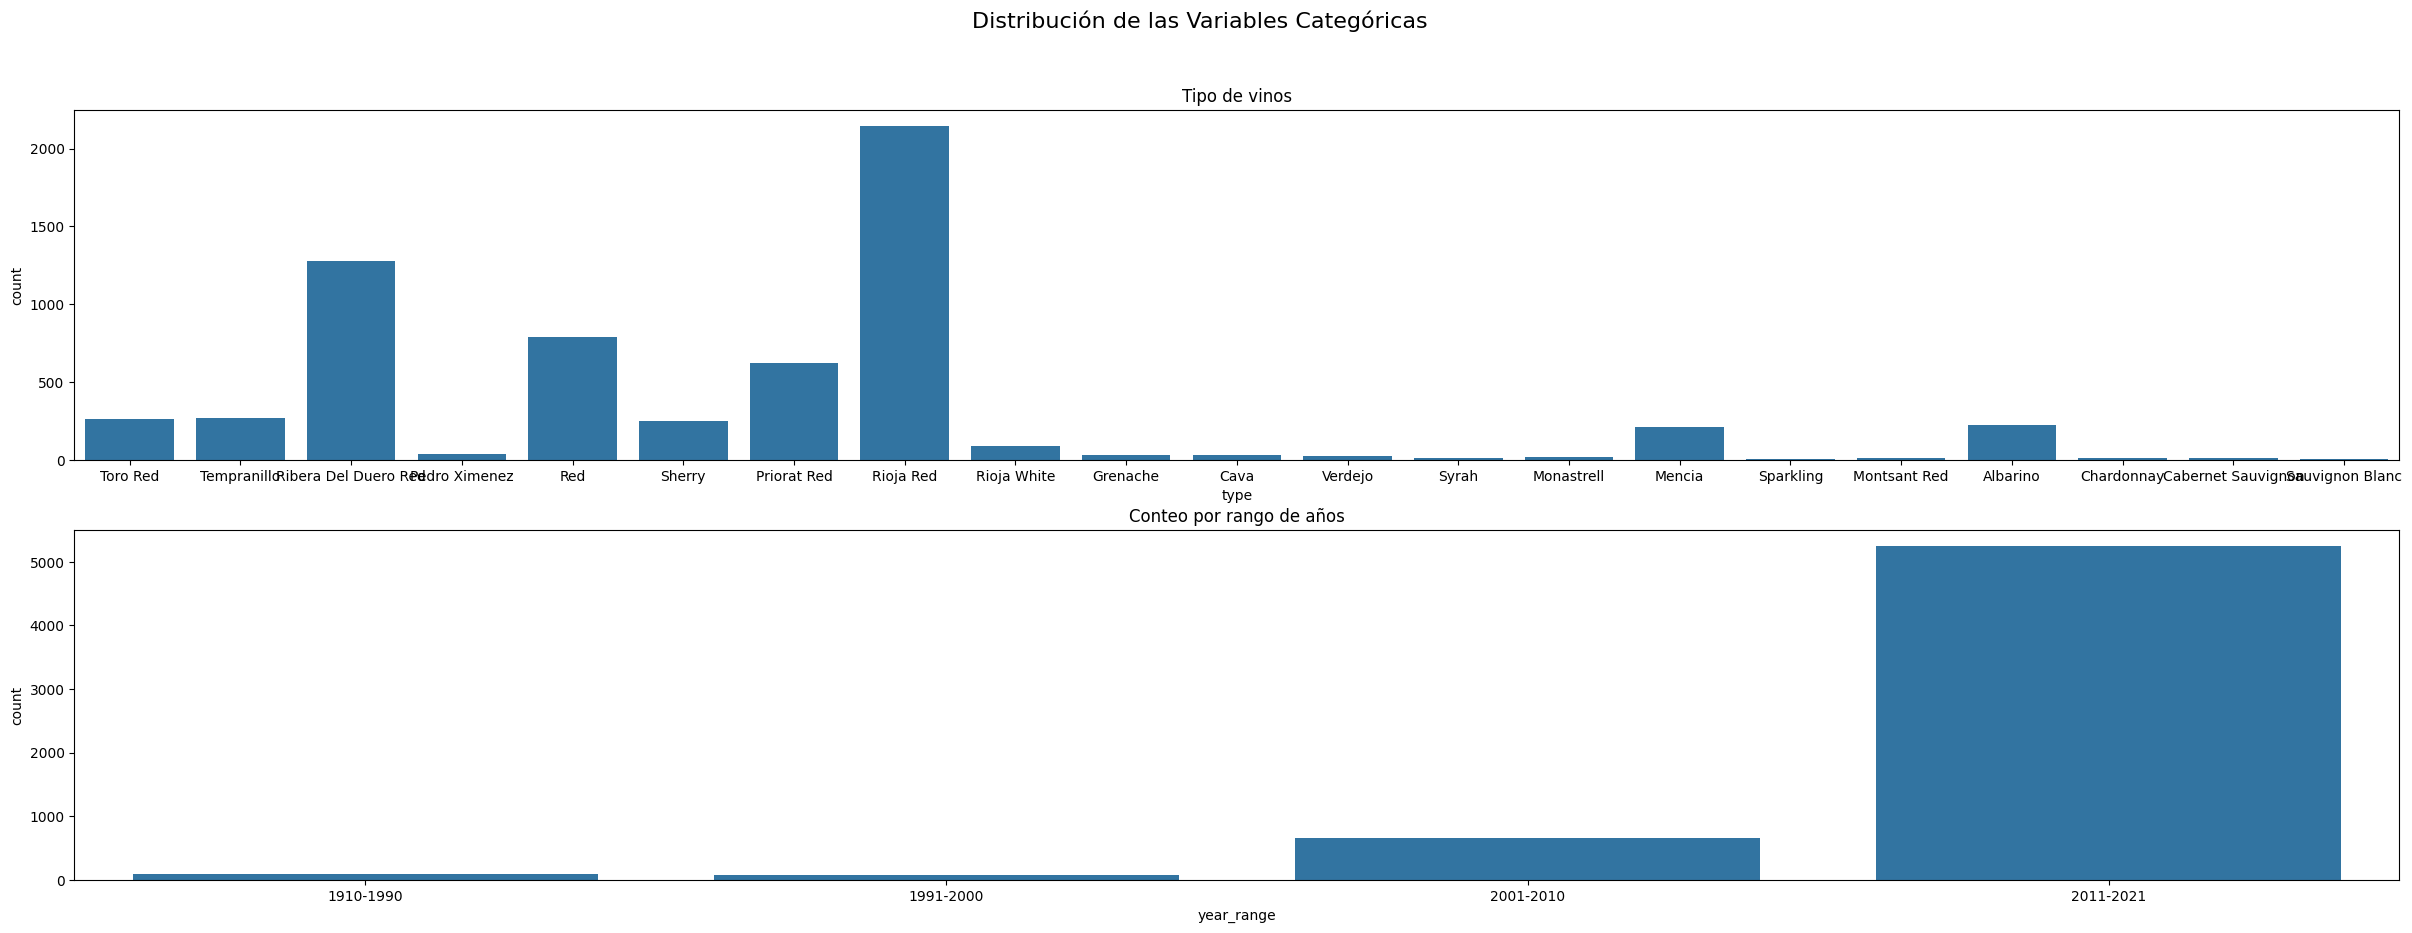

In [23]:
df_wines['year'] = df_wines['year'].replace('N.V.', pd.NA) # reemplazar NV por NaN
df_wines['year'] = pd.to_numeric(df_wines['year'], errors='coerce') # Cambiamos a numerico el año
bins = [1910, 1990, 2000, 2010, 2021] # Creamos lista de los años de referencia
labels = ['1910-1990', '1991-2000', '2001-2010', '2011-2021'] # Creamos las etiquetas de los rangos de años
df_wines['year_range'] = pd.cut(df_wines['year'], bins=bins, labels=labels) # Se crea nueva columna en el dataset
fig, axes = plt.subplots(2, 1, figsize=(30, 10)) # Gráfico que contiene 2 subgráficos (2 fila x 1 columnas)
fig.suptitle('Distribución de las Variables Categóricas', fontsize=16)
sns.countplot(data=df_wines, x='type', ax=axes[0])
sns.countplot(data=df_wines, x='year_range', ax=axes[1])
axes[0].set_title('Tipo de vinos')
axes[1].set_title('Conteo por rango de años')

+ Se observa de modo gráfico lo comentado anteriormente:
    - La mayoría de los vinos son tintos, de los cuales Rioja y Ribera son los más presentes.
    - En cuanto a los años desde el 2011 hasta el 2021 es donde se concentran la mayoria de los vinos, siendo unos pocos los que hay del 2001 al 2010 y unos residuales de 1910 al 2000.

## 📈 Análisis Bivariado

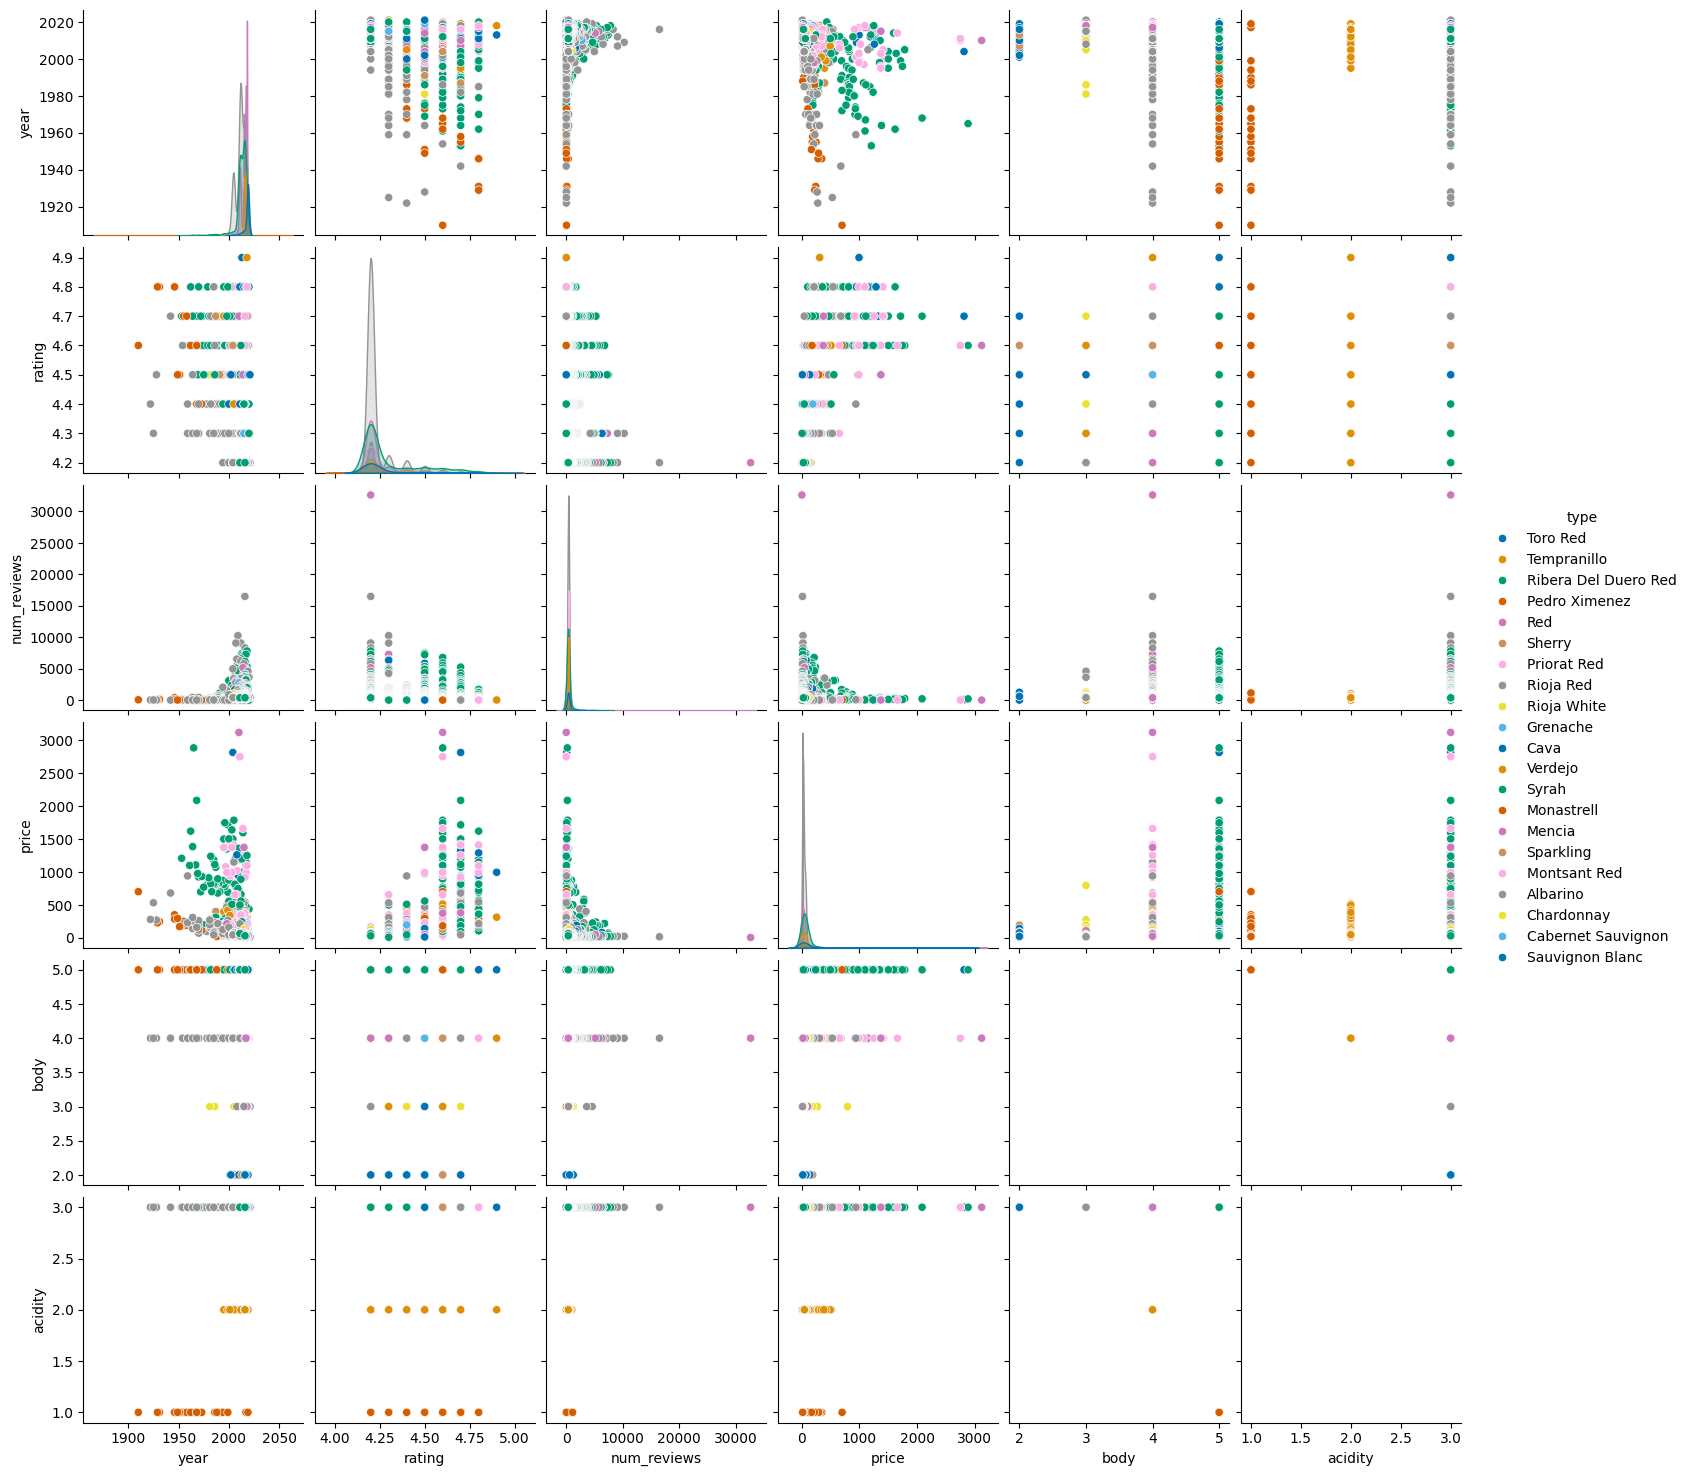

In [24]:
sns.pairplot(df_wines, hue='type', palette='colorblind')

+ Relaciones entre variables

    - **price vs. num_reviews :** parece haber una tendencia débil: algunos vinos caros tienen muchas reseñas, pero en general no hay una correlación clara.
    Esto sugiere que el precio no determina la popularidad (reseñas). Hay muchas reseñas 
    - **price vs. rating :** No se observa correlación fuerte ya que incluso vinos con precios bajos tienen calificaciones altas o más altas que otros vinos más caros.
    - **year vs. price :** no se ve una tendencia fuerte. Algunos vinos antiguos sí son más caros, pero no siempre. Si es verdad que en el caso de los Ribera esta tendencia coge algo más de fuerza, esto es debido a los vinos Únicos de bodegas de gran prestigio como Vega Sicilia entre otros.
    - **body vs. acidity :** No parecen tener una relación lineal con variables como el precio, la puntuación o las reseñas. En cambio según el tipo de vino (tinto o Blanco) presentan diferencias en cuanto a cuerpo y acidez. Los blancos tienen una mayor acidez y menor cuerpo y por el contrario los tintos presentan mayor cuerpo y una acidez algo menor en algunos casos.
    

#### Relación entre la variable numérica precio y la regiones de Ribera, Rioja, Priorat y Toro:
+ Al tratarse de los vinos más presentes vamos a ver su relación respecto al precio.

<Axes: xlabel='region', ylabel='price'>

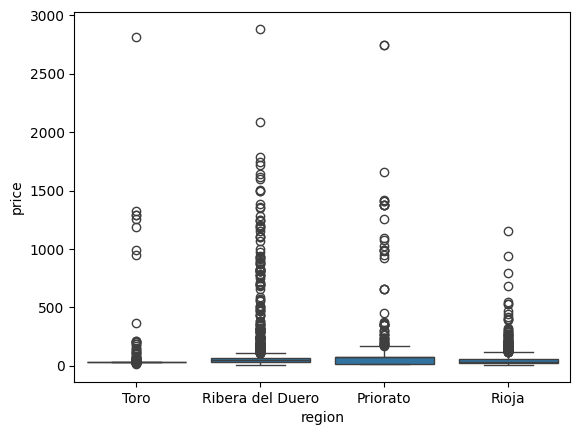

In [27]:
# Filtrar los regiones deseadas
filtro = df_wines['region'].isin(['Ribera del Duero', 'Rioja', 'Toro', 'Priorato'])

sns.boxplot(data=df_wines[filtro], x='region', y='price')

+ Se puede observar que los vinos de la Ribera son más caros que los de la Rioja, si bien hay una gran mayoría que comparten precios. Esto puede ser debido a los vinos Únicos, los cuales presentan precios bastante más elevados y son de la denominación Ribera del Duero principalmente.
+ En lo relativo a los vinos de la región de Toro y de Priorat tambié presentan algún vino más caro pero la mayoría se concentran en precios bajos, cabe destacar que los de la región Priorat el vino de menor precio es algo mayor que sus rivales: Ribera, Rioja y Toro.

#### Relación entre la variable numérica precio y la tipos de vino: Rioja White, Verdejo y Albarino:

<Axes: xlabel='type', ylabel='price'>

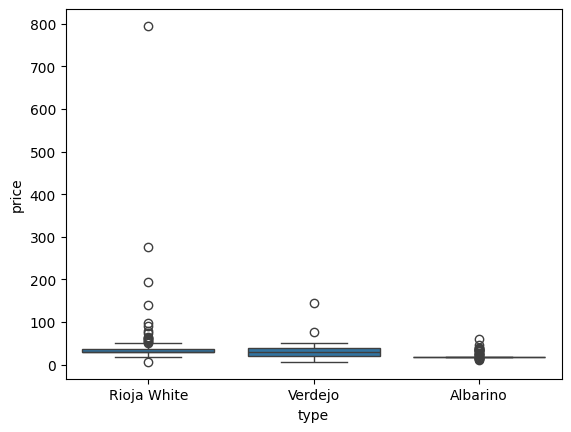

In [26]:
filtro = df_wines['type'].isin(['Rioja White', 'Verdejo', 'Albarino'])

sns.boxplot(data=df_wines[filtro], x='type', y='price')

+ Podemos deducir que el precio de los vinos blancos es menor que el de los tintos y aunque hay algún vino blanco caro en Rioja principalmente, la tendencia es que son más baratos.

#### Relación entre la variable numérica reseñas y la regiones de Ribera, Rioja, Priorat y Toro:

<Axes: xlabel='region', ylabel='num_reviews'>

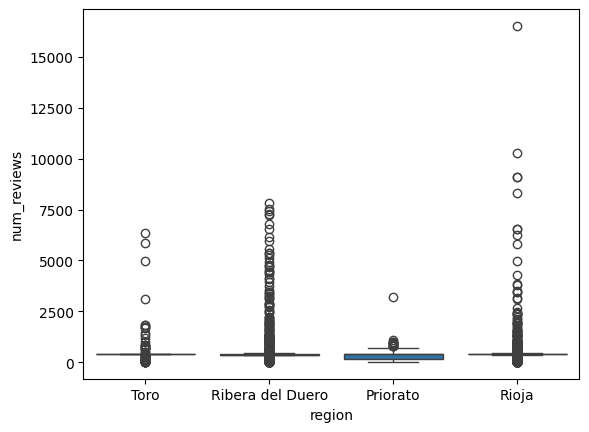

In [29]:
filtro = df_wines['region'].isin(['Ribera del Duero', 'Rioja', 'Toro', 'Priorato'])
sns.boxplot(data=df_wines[filtro], x='region', y='num_reviews')

+ Las regiones de Rioja y Ribera son las que más reseñas presentan de sus vinos (cabe destacar algunas de los vinos de Rioja que superan las 10.000 reseñas)
+ También es destacable que la región de Toro presenta reseñas altas pese a que es la que menos vinos tiene de los cuatro evaluados.

#### Relación entre la variable numérica reseñas y la tipos de vino: Rioja White, Verdejo y Albarino:

<Axes: xlabel='type', ylabel='num_reviews'>

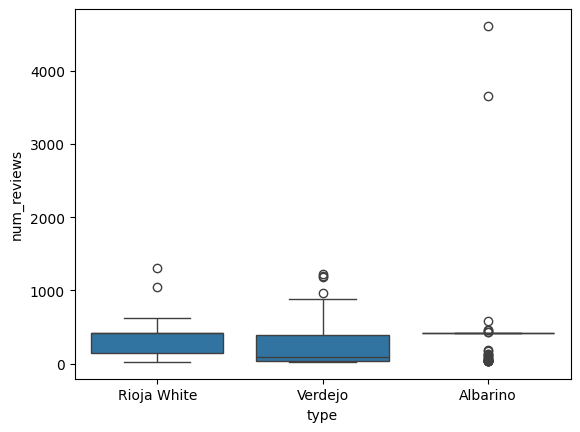

In [28]:
filtro = df_wines['type'].isin(['Rioja White', 'Verdejo', 'Albarino'])

sns.boxplot(data=df_wines[filtro], x='type', y='num_reviews')

+ Los vinos blancos, pese a tener una presencia muy inferior en el dataset con respecto a los vinos tintos, cabe destacar que presentan bastantes reseñas como el caso del Albarino.

# 🤖 Creación de un Modelo de Machine Learning

### 1. Preparar los datos para el modelo

In [38]:

df_wines['type'].unique()  

array(['Toro Red', 'Tempranillo', 'Ribera Del Duero Red', 'Pedro Ximenez',
       'Red', 'Sherry', 'Priorat Red', 'Rioja Red', 'Rioja White',
       'Grenache', 'Cava', 'Verdejo', 'Syrah', 'Monastrell', 'Mencia',
       'Sparkling', 'Montsant Red', 'Albarino', 'Chardonnay',
       'Cabernet Sauvignon', 'Sauvignon Blanc'], dtype=object)

In [39]:
map_target_class = {'Toro Red' : 0, 'Tempranillo':1, 'Ribera Del Duero Red':2, 'Pedro Ximenez':3,
                    'Red':5, 'Sherry':6, 'Priorat Red': 7, 'Rioja Red':8, 'Rioja White':9, 'Grenache':10,
                    'Cava': 11, 'Verdejo':12, 'Syrah':13, 'Monastrell':14, 'Mencia':15, 'Sparkling': 16, 'Montsant Red':17
                    , 'Albarino': 18, 'Chardonnay':19, 'Cabernet Sauvignon':20, 'Sauvignon Blanc':21}

df_wines['type_numerical'] = df_wines['type'].map(map_target_class)
df_wines.head(5)

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity,year_range,type_numerical
0,Teso La Monja,Tinto,2013.0,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0,2011-2021,0
1,Artadi,Vina El Pison,2018.0,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0,2011-2021,1
2,Vega Sicilia,Unico,2009.0,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0,2001-2010,2
3,Vega Sicilia,Unico,1999.0,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0,1991-2000,2
4,Vega Sicilia,Unico,1996.0,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0,1991-2000,2
